# **Análise baseada especifica baseada na região Crajubar Incuindo as tabelas com as informações do SISCAN**

> Totais de Cidades inclusas na análise: 3

Barbalha, Crato, Juazeiro do Norte.

Análise reduzida para verificar os Outliers na região Crajubar com o acrescimo de informações como Etinia e Idade.

Para a Analise foi utilizados os datasets mamografia_crajubar, mamografia_etnia_crajubar e mamografia_faixa_crajubar.

#### _Importando as dependencias_

In [23]:
import pandas as pd                          # Manipulação dos dados
import numpy as np                           # Calculos Matmáticos
import matplotlib.pyplot as plt              # Geração de Gráficos
import seaborn as sns                        # Graficos automaticos, baseado no matplotlib
import statistics as sta                     # Biblioteca padrão do py para estatistica
from scipy import stats                      # Estastistica avançada

import warnings                              # Limpando tela de comentarios py, esconde os warnings
warnings.filterwarnings('ignore')

### **Limpeza e Preparação**

In [24]:
df_mamo_crajubar = pd.read_csv('../../Datasets/N2/mamografia_crajubar.csv')
mamo_crajubar = df_mamo_crajubar.drop(columns=['Unnamed: 0'])
mamo_crajubar = mamo_crajubar[mamo_crajubar['valor_indicador'] != 0]
print(mamo_crajubar.columns.tolist())
mamo_crajubar.head(30)

['Unnamed: 0.1', 'estado', 'municipio', 'valor_indicador', 'ano_mes', 'tipo_exame']


,Unnamed: 0.1,estado,municipio,valor_indicador,ano_mes,tipo_exame
1,11,CE,CRATO,948,201612,Mamografia
3,34,CE,BARBALHA,1747,201712,Mamografia
4,39,CE,CRATO,2285,201712,Mamografia
5,44,CE,JUAZEIRO DO NORTE,1468,201712,Mamografia
6,62,CE,BARBALHA,2479,201812,Mamografia
7,67,CE,CRATO,1233,201812,Mamografia
8,72,CE,JUAZEIRO DO NORTE,3061,201812,Mamografia
9,90,CE,BARBALHA,2115,201912,Mamografia
10,95,CE,CRATO,2,201912,Mamografia
11,100,CE,JUAZEIRO DO NORTE,4738,201912,Mamografia


#### _Visão geral_

Observação e primeira visão dos dados e tipos de dados:
- Tipo de valor, valores nulos, valores unicos (quantidade de valores diferentes)... 
-  Verificação das variáveis disponíveis e suas escalas (nominal, ordinal, discreta, contínua, intervalar, etc.).

Estastica: 
- Média, Mediana, Mínimo, Máximo e Desvio padrão para a coluna do valor_indicador

> Foi utilizado a métrica IQR por não ser sensível a Outlier como a métrica tradicional


##### _Classificação das variáveis por escala de medida_

Aqui pegamos o tipo, escala e valores unicos e de cada coluna e criamos uma tabela para as informações

In [25]:
def infer_scale(column_series):
    if pd.api.types.is_datetime64_any_dtype(column_series):
        return 'Temporal (intervalar/razão)'

    if column_series.dtype == 'string' or column_series.dtype == object:
        try:
            converted = pd.to_datetime(column_series, errors='coerce')
            if converted.notna().sum() / len(column_series) > 0.9:
                return 'Temporal (intervalar/razão) - string'
        except Exception:
            pass
        return 'Nominal'  # strings são normalmente nominais

    if pd.api.types.is_categorical_dtype(column_series):
        if getattr(column_series.dtype, 'ordered', False):
            return 'Ordinal'
        return 'Nominal'

    if pd.api.types.is_integer_dtype(column_series):
        unique = column_series.nunique(dropna=True)
        if unique < 30:
            return 'Discreta (categoria numérica/ordinal)'
        return 'Discreta'

    if pd.api.types.is_float_dtype(column_series):
        return 'Contínua'

    return 'Desconhecida'

scale_info = []
for col in mamo_crajubar.columns:
    dtype = mamo_crajubar[col].dtype
    scale = infer_scale(mamo_crajubar[col])
    scale_info.append({'coluna': col, 'tipo': str(dtype), 'escala': scale, 'valores_unicos': mamo_crajubar[col].nunique(dropna=True)})

scale_df = pd.DataFrame(scale_info)
scale_df


,coluna,tipo,escala,valores_unicos
0,Unnamed: 0.1,int64,Discreta (categoria numérica/ordinal),25
1,estado,str,Nominal,1
2,municipio,str,Nominal,3
3,valor_indicador,int64,Discreta (categoria numérica/ordinal),25
4,ano_mes,int64,Discreta (categoria numérica/ordinal),9
5,tipo_exame,str,Nominal,1


##### _Entendimento mais detalhado_

In [26]:
print("# DOCUMENTAÇÃO DO DATASET - EXAMES DE MAMOGRAFIA\n")
print("## Visão Geral")
print(f"- **Total de registros**: {len(mamo_crajubar):,}")
print(f"- **Total de colunas**: {(mamo_crajubar.columns)}")
print(f"- **Última atualização**: 24 de novembro de 2025\n")

print("## Descrição Detalhada das Colunas\n")

for i, column in enumerate(mamo_crajubar.columns, 1):
    print(f"### {i}. {column}")
    print(f"**Tipo de dado**: {mamo_crajubar[column].dtype}")
    print(f"**Valores únicos**: {mamo_crajubar[column].nunique():,}")
    print(f"**Valores nulos**: {mamo_crajubar[column].isnull().sum():,} ({mamo_crajubar[column].isnull().sum()/len(mamo_crajubar)*100:.1f}%)")

    if mamo_crajubar[column].dtype in ['float64']:
        print("**Estatísticas**:")
        print(f"  - Média: {mamo_crajubar[column].mean():,.2f}")
        print(f"  - Mediana: {mamo_crajubar[column].median():,.2f}")
        print(f"  - Mínimo: {mamo_crajubar[column].min():,}")
        print(f"  - Máximo: {mamo_crajubar[column].max():,}")

        q1 = mamo_crajubar[column].quantile(0.25)
        q3 = mamo_crajubar[column].quantile(0.75)
        iqr = q3 - q1
        std_robust = iqr / 1.349  # Fórmula robusta: σ ≈ IQR / 1.349 (para distribuição normal)
        print(f"  - Desvio padrão: {std_robust:,.2f}")
        print(f"  - IQR (Intervalo Interquartílico): {iqr:,.2f}")
    else:
        unique_values = mamo_crajubar[column].dropna().unique()
        if len(unique_values) <= 10:
            print(f"**Valores únicos**: {', '.join(str(v) for v in unique_values)}")
        else:
            print(f"**Primeiros valores únicos**: {', '.join(str(v) for v in unique_values[:10])}...")

    print()

print("---")
print("*Documentação gerada automaticamente em", pd.Timestamp.now().strftime("%d/%m/%Y %H:%M"))

# DOCUMENTAÇÃO DO DATASET - EXAMES DE MAMOGRAFIA

## Visão Geral
- **Total de registros**: 25
- **Total de colunas**: Index(['Unnamed: 0.1', 'estado', 'municipio', 'valor_indicador', 'ano_mes',
       'tipo_exame'],
      dtype='str')
- **Última atualização**: 24 de novembro de 2025

## Descrição Detalhada das Colunas

### 1. Unnamed: 0.1
**Tipo de dado**: int64
**Valores únicos**: 25
**Valores nulos**: 0 (0.0%)
**Primeiros valores únicos**: 11, 34, 39, 44, 62, 67, 72, 90, 95, 100...

### 2. estado
**Tipo de dado**: str
**Valores únicos**: 1
**Valores nulos**: 0 (0.0%)
**Valores únicos**: CE

### 3. municipio
**Tipo de dado**: str
**Valores únicos**: 3
**Valores nulos**: 0 (0.0%)
**Valores únicos**: CRATO, BARBALHA, JUAZEIRO DO NORTE

### 4. valor_indicador
**Tipo de dado**: int64
**Valores únicos**: 25
**Valores nulos**: 0 (0.0%)
**Primeiros valores únicos**: 948, 1747, 2285, 1468, 2479, 1233, 3061, 2115, 2, 4738...

### 5. ano_mes
**Tipo de dado**: int64
**Valores únicos**: 9
**Valor

#### _Desvio padrão e seus detalhamentos_

Nesse ponto foi utilizado a métrica IQR, para facilitar a captura de outliers

MÉTRICA: IQR - INTERVALO INTERQUARTÍLICO <br>
O que é:

> O IQR divide os dados em 4 partes iguais (quartis). <br>
> Valores que saem dos limites IQR são considerados outliers.

In [27]:
print("MÉTRICAS DE PADRÃO E DETECÇÃO DE ANOMALIAS")

if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador']
    
    print(f"\n MÉTRICA: IQR - INTERVALO INTERQUARTÍLICO")
    print("-" * 100)
    
    q1 = valor_indicador.quantile(0.25)
    q2 = valor_indicador.quantile(0.50)
    q3 = valor_indicador.quantile(0.75)
    iqr = q3 - q1
    
    print(f" VALORES DO DATASET:")
    print(f"   • Q1 (25º percentil): {q1:,.2f}")
    print(f"   • Q2 (50º percentil/Mediana): {q2:,.2f}")
    print(f"   • Q3 (75º percentil): {q3:,.2f}")
    print(f"   • IQR (Q3 - Q1): {iqr:,.2f}")
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    print(f"\n QUANDO FOGE DO PADRÃO (método IQR - 1.5x):")
    print(f"   • Limite inferior: Q1 - 1.5 × IQR = {q1:,.2f} - 1.5 × {iqr:,.2f} = {limite_inferior:,.2f}")
    print(f"   • Limite superior: Q3 + 1.5 × IQR = {q3:,.2f} + 1.5 × {iqr:,.2f} = {limite_superior:,.2f}")
    print(f"   • Outliers: valores < {limite_inferior:,.2f} ou > {limite_superior:,.2f}")
    
    outliers_iqr = valor_indicador[(valor_indicador < limite_inferior) | (valor_indicador > limite_superior)]
    
    print(f"\n NO DATASET:")
    print(f"   • Total de outliers (IQR): {len(outliers_iqr)} ({len(outliers_iqr)/len(valor_indicador)*100:.1f}%)")
    print(f"   • Valores mínimo/máximo reais: {valor_indicador.min():,.2f} / {valor_indicador.max():,.2f}")
    
    print(f"   • Valores fora do intervalo [{limite_inferior:,.2f}, {limite_superior:,.2f}] são anomalias")

else:
    print(" Coluna 'valor_indicador' não encontrada no dataset!")

MÉTRICAS DE PADRÃO E DETECÇÃO DE ANOMALIAS

 MÉTRICA: IQR - INTERVALO INTERQUARTÍLICO
----------------------------------------------------------------------------------------------------
 VALORES DO DATASET:
   • Q1 (25º percentil): 1,869.00
   • Q2 (50º percentil/Mediana): 2,314.00
   • Q3 (75º percentil): 3,022.00
   • IQR (Q3 - Q1): 1,153.00

 QUANDO FOGE DO PADRÃO (método IQR - 1.5x):
   • Limite inferior: Q1 - 1.5 × IQR = 1,869.00 - 1.5 × 1,153.00 = 139.50
   • Limite superior: Q3 + 1.5 × IQR = 3,022.00 + 1.5 × 1,153.00 = 4,751.50
   • Outliers: valores < 139.50 ou > 4,751.50

 NO DATASET:
   • Total de outliers (IQR): 2 (8.0%)
   • Valores mínimo/máximo reais: 2.00 / 5,027.00
   • Valores fora do intervalo [139.50, 4,751.50] são anomalias


Mostrando quem faz parte desse desvio...

In [28]:
print("ANOMALIAS DETECTADAS: Linhas que Fogem do Padrão (Outliers via IQR)")

if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador']

    q1 = valor_indicador.quantile(0.25)
    q3 = valor_indicador.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_df = mamo_crajubar[(valor_indicador < limite_inferior) | (valor_indicador > limite_superior)].copy()

    outliers_df['tipo_outlier'] = outliers_df['valor_indicador'].apply(
        lambda x: 'Abaixo da Métrica' if x < limite_inferior else 'Acima da Métrica'
    )

    mediana = valor_indicador.median()
    outliers_df['desvio_mediana'] = outliers_df['valor_indicador'] - mediana

    print(f"\n RESUMO DOS OUTLIERS:")
    print(f"-" * 50)
    print(f"Total de registros no dataset: {len(mamo_crajubar)}")
    print(f"Total de outliers detectados: {len(outliers_df)} ({len(outliers_df)/len(mamo_crajubar)*100:.1f}%)")
    print(f"Limites IQR: [{limite_inferior:,.2f}, {limite_superior:,.2f}]")
    print(f"Mediana do dataset: {mediana:,.2f}\n")

    if len(outliers_df) > 0:
        print(f"TABELA COMPLETA DOS OUTLIERS:")
        print(f"-" * 120)

        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)

        cols_importantes = ['valor_indicador', 'tipo_outlier', 'desvio_mediana']
        outras_cols = [col for col in outliers_df.columns if col not in cols_importantes]
        ordem_cols = cols_importantes + outras_cols

        print(outliers_df[ordem_cols].to_string(index=True))

        print(f"\n" + "-" * 120)
        print(f"INTERPRETAÇÃO:")
        print(f"- **Outlier Inferior**: Valores muito baixos (abaixo de {limite_inferior:,.2f})")
        print(f"- **Outlier Superior**: Valores muito altos (acima de {limite_superior:,.2f})")
        print(f"- **Desvio da Mediana**: Quanto o valor se afasta da mediana ({mediana:,.2f})")
        print(f"- Valores positivos = acima da mediana | Valores negativos = abaixo da mediana")
        print(f"- Quanto maior o desvio absoluto, mais extrema é a anomalia\n")

        print(f"-" * 50)
        print(f"Valor indicador - Mínimo: {outliers_df['valor_indicador'].min():,.2f}")
        print(f"Valor indicador - Máximo: {outliers_df['valor_indicador'].max():,.2f}")
        print(f"Valor indicador - Média: {outliers_df['valor_indicador'].mean():,.2f}")
        print(f"Desvio da mediana - Médio: {outliers_df['desvio_mediana'].mean():,.2f}")
        print(f"Outliers inferiores: {len(outliers_df[outliers_df['tipo_outlier'] == 'Outlier Inferior'])}")
        print(f"Outliers superiores: {len(outliers_df[outliers_df['tipo_outlier'] == 'Outlier Superior'])}")

    else:
        print("Todos os valores estão dentro dos limites considerados normais pelo método IQR.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

ANOMALIAS DETECTADAS: Linhas que Fogem do Padrão (Outliers via IQR)

 RESUMO DOS OUTLIERS:
--------------------------------------------------
Total de registros no dataset: 25
Total de outliers detectados: 2 (8.0%)
Limites IQR: [139.50, 4,751.50]
Mediana do dataset: 2,314.00

TABELA COMPLETA DOS OUTLIERS:
------------------------------------------------------------------------------------------------------------------------
    valor_indicador       tipo_outlier  desvio_mediana  Unnamed: 0.1 estado          municipio  ano_mes  tipo_exame
10                2  Abaixo da Métrica         -2312.0            95     CE              CRATO   201912  Mamografia
26             5027   Acima da Métrica          2713.0           240     CE  JUAZEIRO DO NORTE   202412  Mamografia

------------------------------------------------------------------------------------------------------------------------
INTERPRETAÇÃO:
- **Outlier Inferior**: Valores muito baixos (abaixo de 139.50)
- **Outlier Superior**:

#### _Padrões iniciais_

> Aqui foi utilizado valores de referencia Benchmarks: 

Benchmarks de referência são valores-padrão estabelecidos por organizações de saúde internacionais e nacionais para medir a qualidade e cobertura dos serviços de saúde.

Eles servem como: <br>
• Metas a serem alcançadas<br>
• Padrões para comparar diferentes regiões/países<br>
• Indicadores de qualidade dos serviços<br>
• Base para políticas públicas<br>
• Critérios para alocação de recursos<br>

Fonte dos Benchmarks utilizadas: <br>
1. ORGANIZAÇÃO MUNDIAL DA SAÚDE (OMS)<br>
2. INSTITUTO NACIONAL DE CÂNCER (INCA) - Brasil<br>
3. MINISTÉRIO DA SAÚDE - Brasil<br>
4. AMERICAN CANCER SOCIETY (ACS)<br>
5. UNIÃO INTERNACIONAL CONTRA O CÂNCER (UICC)

In [30]:
print("ESTABELECIMENTO DE PADRÕES INICIAIS - BENCHMARKS PARA ANÁLISE\n")

if 'valor_indicador' in mamo_crajubar.columns and 'tipo_exame' in mamo_crajubar.columns:
    print("PADRÕES ESTATÍSTICOS GERAIS")
    print("-" * 60)

    media_geral = mamo_crajubar['valor_indicador'].mean()
    mediana_geral = mamo_crajubar['valor_indicador'].median()
    desvio_padrao_geral = mamo_crajubar['valor_indicador'].std()
    q1_geral = mamo_crajubar['valor_indicador'].quantile(0.25)
    q3_geral = mamo_crajubar['valor_indicador'].quantile(0.75)
    iqr_geral = q3_geral - q1_geral

    print("ESTATÍSTICAS DESCRITIVAS GERAIS:")
    print(f"   • Média geral: {media_geral:,.2f}")
    print(f"   • Mediana geral: {mediana_geral:,.2f}")
    print(f"   • Desvio padrão: {desvio_padrao_geral:,.2f}")
    print(f"   • Q1 (25º percentil): {q1_geral:,.2f}")
    print(f"   • Q3 (75º percentil): {q3_geral:,.2f}")
    print(f"   • IQR: {iqr_geral:,.2f}")

    print(f"\nPADRÕES POR TIPO DE EXAME")
    print("-" * 60)

    tipos_exame = mamo_crajubar['tipo_exame'].unique()
    padroes_por_tipo = {}

    for tipo in tipos_exame:
        if pd.notna(tipo):
            dados_tipo = mamo_crajubar[mamo_crajubar['tipo_exame'] == tipo]['valor_indicador']
            if len(dados_tipo) > 0:
                padroes_por_tipo[tipo] = {
                    'media': dados_tipo.mean(),
                    'mediana': dados_tipo.median(),
                    'desvio_padrao': dados_tipo.std(),
                    'q1': dados_tipo.quantile(0.25),
                    'q3': dados_tipo.quantile(0.75),
                    'iqr': dados_tipo.quantile(0.75) - dados_tipo.quantile(0.25),
                    'min': dados_tipo.min(),
                    'max': dados_tipo.max(),
                    'contagem': len(dados_tipo)
                }

    for tipo, stats in padroes_por_tipo.items():
        print(f"\nPADRÃO PARA {tipo.upper()}:")
        print(f"   • Contagem: {stats['contagem']:,} registros")
        print(f"   • Média: {stats['media']:,.2f}")
        print(f"   • Mediana: {stats['mediana']:,.2f}")
        print(f"   • Desvio padrão: {stats['desvio_padrao']:,.2f}")
        print(f"   • Intervalo IQR: [{stats['q1']:,.2f}, {stats['q3']:,.2f}]")
        print(f"   • Amplitude: {stats['min']:,.2f} - {stats['max']:,.2f}")

    if 'ano_mes' in mamo_crajubar.columns:
        print(f"\nPADRÕES TEMPORAIS POR ANO")
        print("-" * 60)

        mamo_crajubar['ano'] = mamo_crajubar['ano_mes'].astype(str).str[:4].astype(int)
        anos_unicos = sorted(mamo_crajubar['ano'].unique())

        padroes_temporais = {}
        for ano in anos_unicos:
            dados_ano = mamo_crajubar[mamo_crajubar['ano'] == ano]['valor_indicador']
            if len(dados_ano) > 0:
                padroes_temporais[ano] = {
                    'media': dados_ano.mean(),
                    'mediana': dados_ano.median(),
                    'total_exames': dados_ano.sum(),
                    'contagem': len(dados_ano)
                }

        for ano, stats in padroes_temporais.items():
            print(f"\nPADRÃO PARA {ano}:")
            print(f"   • Total de exames: {stats['total_exames']:,.0f}")
            print(f"   • Contagem de registros: {stats['contagem']:,}")
            print(f"   • Média por registro: {stats['media']:,.2f}")
            print(f"   • Mediana por registro: {stats['mediana']:,.2f}")

    print(f"\nPADRÕES DE SAÚDE PÚBLICA - BENCHMARKS DE REFERÊNCIA")
    print("-" * 60)

    benchmarks = {
        'cobertura_minima_mamografia': 60,   # % da população feminina > 40 anos
        'frequencia_ideal_mamografia': 1,    # exame por ano para > 40 anos
        'taxa_detectada_cancer': 0.002,     # 0.2% da população (estimativa)
        'meta_reducao_mortalidade': 0.05     # 5% de redução anual
    }

    print("BENCHMARKS DE SAÚDE PÚBLICA (valores de referência):")
    print(f"   • Cobertura mínima mamografia: {benchmarks['cobertura_minima_mamografia']}% da população > 40 anos")
    print(f"   • Frequência ideal mamografia: {benchmarks['frequencia_ideal_mamografia']} exame/ano para > 40 anos")
    print(f"   • Taxa esperada de detecção de câncer: {benchmarks['taxa_detectada_cancer']*100:.1f}% da população")
    print(f"   • Meta de redução da mortalidade: {benchmarks['meta_reducao_mortalidade']*100:.0f}% ao ano")

    print(f"\nCRITÉRIOS PARA CLASSIFICAÇÃO DE PADRÕES")
    print("-" * 60)

    criterios = {
        'excelente': {'limite_inferior': q3_geral + iqr_geral, 'cor': '🟢', 'descricao': 'Acima do Q3 + IQR'},
        'bom': {'limite_inferior': q3_geral, 'limite_superior': q3_geral + iqr_geral, 'cor': '🟡', 'descricao': 'Entre Q3 e Q3 + IQR'},
        'regular': {'limite_inferior': q1_geral, 'limite_superior': q3_geral, 'cor': '🟠', 'descricao': 'Entre Q1 e Q3'},
        'baixo': {'limite_superior': q1_geral, 'cor': '🔴', 'descricao': 'Abaixo do Q1'},
        'critico': {'limite_superior': q1_geral - iqr_geral, 'cor': '⚫', 'descricao': 'Abaixo do Q1 - IQR'}
    }

    print("CRITÉRIOS DE CLASSIFICAÇÃO BASEADOS EM QUARTIS:")
    for nivel, criterio in criterios.items():
        print(f"   • {criterio['cor']} {nivel.upper()}: {criterio['descricao']}")

    print(f"\nFUNÇÃO PARA CLASSIFICAR VALORES SEGUNDO OS PADRÕES")
    print("-" * 60)

    def classificar_valor(valor, criterios=criterios):
        """Classifica um valor segundo os critérios estabelecidos"""
        if valor >= criterios['excelente']['limite_inferior']:
            return 'excelente'
        elif valor >= criterios['bom']['limite_inferior']:
            return 'bom'
        elif valor >= criterios['regular']['limite_inferior']:
            return 'regular'
        elif valor >= criterios['baixo']['limite_superior']:
            return 'baixo'
        else:
            return 'critico'

    exemplo_valor = media_geral
    classificacao = classificar_valor(exemplo_valor)
    print(f"\nEXEMPLO DE CLASSIFICAÇÃO:")
    print(f"   • Valor: {exemplo_valor:,.2f}")
    print(f"   • Classificação: {criterios[classificacao]['cor']} {classificacao.upper()}")
    print(f"   • Descrição: {criterios[classificacao]['descricao']}")

    print("RESUMO DOS PADRÕES ESTABELECIDOS")

    print("\nPADRÕES DEFINIDOS:")
    print("   • Estatísticas descritivas gerais (média, mediana, desvio padrão, quartis)")
    print("   • Padrões específicos por tipo de exame")
    print("   • Padrões temporais por ano (se tiver...)")
    print("   • Benchmarks de saúde pública")
    print("   • Critérios de classificação (excelente, bom, regular, baixo, crítico)")
    print("   • Função de classificação automática")

    print("\nUTILIDADE DOS PADRÕES:")
    print("   • Comparar cidades/regiões contra benchmarks")
    print("   • Identificar áreas que precisam de intervenção")
    print("   • Avaliar evolução temporal dos indicadores")
    print("   • Classificar automaticamente o desempenho")
    print("   • Estabelecer metas realistas baseadas em dados históricos")

else:
    print("Colunas necessárias não encontradas no dataset!")
    print("Colunas necessárias: 'valor_indicador', 'tipo_exame'")
    print("Colunas disponíveis:", mamo_crajubar.columns.tolist())

ESTABELECIMENTO DE PADRÕES INICIAIS - BENCHMARKS PARA ANÁLISE

PADRÕES ESTATÍSTICOS GERAIS
------------------------------------------------------------
ESTATÍSTICAS DESCRITIVAS GERAIS:
   • Média geral: 2,491.44
   • Mediana geral: 2,314.00
   • Desvio padrão: 1,151.69
   • Q1 (25º percentil): 1,869.00
   • Q3 (75º percentil): 3,022.00
   • IQR: 1,153.00

PADRÕES POR TIPO DE EXAME
------------------------------------------------------------

PADRÃO PARA MAMOGRAFIA:
   • Contagem: 25 registros
   • Média: 2,491.44
   • Mediana: 2,314.00
   • Desvio padrão: 1,151.69
   • Intervalo IQR: [1,869.00, 3,022.00]
   • Amplitude: 2.00 - 5,027.00

PADRÕES TEMPORAIS POR ANO
------------------------------------------------------------

PADRÃO PARA 2016:
   • Total de exames: 948
   • Contagem de registros: 1
   • Média por registro: 948.00
   • Mediana por registro: 948.00

PADRÃO PARA 2017:
   • Total de exames: 5,500
   • Contagem de registros: 3
   • Média por registro: 1,833.33
   • Mediana por

### **Análise Exploratória (EDA- Exploratory Data Analysis) Parte 1**

##### _Medidas de posições_

> - Média: Valor central aritmético <br>
> - Mediana: Valor central quando ordenado <br>
> - Moda: Valor(es) mais frequente(s)

In [31]:
if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador'].dropna()  # Remover NaN para cálculos

    print("MEDIDAS DE POSIÇÃO")
    print("-" * 50)

    media = valor_indicador.mean()
    mediana = valor_indicador.median()
    moda = valor_indicador.mode()

    print(f"Média: {media:,.2f}")
    print(f"Mediana: {mediana:,.2f}")
    if len(moda) > 0:
        if len(moda) == 1:
            print(f"Moda: {moda.iloc[0]:,.2f}")
        else:
            print(f"Modas ({len(moda)}): {', '.join([f'{m:,.2f}' for m in moda])}")
    else:
        print("Moda: Não existe (distribuição uniforme)")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

MEDIDAS DE POSIÇÃO
--------------------------------------------------
Média: 2,491.44
Mediana: 2,314.00
Modas (25): 2.00, 948.00, 1,233.00, 1,468.00, 1,681.00, 1,747.00, 1,869.00, 1,929.00, 2,106.00, 2,115.00, 2,285.00, 2,294.00, 2,314.00, 2,333.00, 2,453.00, 2,479.00, 2,599.00, 2,927.00, 3,022.00, 3,061.00, 3,590.00, 3,901.00, 4,165.00, 4,738.00, 5,027.00


##### _Separatrizes (Quartis e Percentis)_

> - Quartis: Q1 (25%), Q2 (50% - mediana), Q3 (75%) <br>
> - Percentis: P10, P90, P95

In [32]:
if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nSEPARATRIZES")
    print("-" * 50)

    q1 = valor_indicador.quantile(0.25)
    q2 = valor_indicador.quantile(0.50)  # Mesmo que mediana
    q3 = valor_indicador.quantile(0.75)

    print(f"Quartis:")
    print(f"      • Q1 (25º percentil): {q1:,.2f}")
    print(f"      • Q2 (50º percentil/Mediana): {q2:,.2f}")
    print(f"      • Q3 (75º percentil): {q3:,.2f}")

    # Percentis adicionais
    p10 = valor_indicador.quantile(0.10)
    p90 = valor_indicador.quantile(0.90)
    p95 = valor_indicador.quantile(0.95)

    print(f"\nOutros Percentis:")
    print(f"      • P10 (10º percentil): {p10:,.2f}")
    print(f"      • P90 (90º percentil): {p90:,.2f}")
    print(f"      • P95 (95º percentil): {p95:,.2f}")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


SEPARATRIZES
--------------------------------------------------
Quartis:
      • Q1 (25º percentil): 1,869.00
      • Q2 (50º percentil/Mediana): 2,314.00
      • Q3 (75º percentil): 3,022.00

Outros Percentis:
      • P10 (10º percentil): 1,327.00
      • P90 (90º percentil): 4,059.40
      • P95 (95º percentil): 4,623.40


##### _Medidas de dispersão_

> - Amplitude: Diferença entre máximo e mínimo <br>
> - Variância: Média dos quadrados dos desvios <br>
> - Desvio Padrão: Raiz quadrada da variância <br>
> - IQR: Intervalo interquartílico (Q3 - Q1) <br>
> - Coeficiente de Variação: Desvio padrão / média × 100% <br>

In [33]:
if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nMEDIDAS DE DISPERSÃO")
    print("-" * 50)

    amplitude = valor_indicador.max() - valor_indicador.min()

    variancia = valor_indicador.var()

    desvio_padrao = valor_indicador.std()

    iqr = q3 - q1

    cv = (desvio_padrao / media) * 100

    print(f"Amplitude: {amplitude:,.2f}")
    print(f"Variância: {variancia:,.2f}")
    print(f"Desvio Padrão: {desvio_padrao:,.2f}")
    print(f"IQR (Intervalo Interquartílico): {iqr:,.2f}")
    print(f"Coeficiente de Variação: {cv:.2f}%")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


MEDIDAS DE DISPERSÃO
--------------------------------------------------
Amplitude: 5,025.00
Variância: 1,326,385.51
Desvio Padrão: 1,151.69
IQR (Intervalo Interquartílico): 1,153.00
Coeficiente de Variação: 46.23%


##### _Assimetria (SKEWNESS)_

> - Coeficiente: Mede o grau de assimetria <br>
> - Interpretação: Simétrica, assimétrica à direita/esquerda <br>
> - Classificação: Leve, moderada ou forte

In [34]:
if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nASSIMETRIA (SKEWNESS)")
    print("-" * 50)

    skewness = valor_indicador.skew()

    print(f"Coeficiente de Assimetria: {skewness:.4f}")

    if skewness > 0:
        print("Interpretação: Distribuição assimétrica à DIREITA (cauda alongada à direita)")
        print("Significado: Média > Mediana, valores extremos altos mais frequentes")
    elif skewness < 0:
        print("Interpretação: Distribuição assimétrica à ESQUERDA (cauda alongada à esquerda)")
        print("Significado: Média < Mediana, valores extremos baixos mais frequentes")
    else:
        print("Interpretação: Distribuição SIMÉTRICA (aproximadamente normal)")

    if abs(skewness) < 0.5:
        print("Classificação: Assimetria LEVE")
    elif abs(skewness) < 1.0:
        print("Classificação: Assimetria MODERADA")
    else:
        print("Classificação: Assimetria FORTE")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


ASSIMETRIA (SKEWNESS)
--------------------------------------------------
Coeficiente de Assimetria: 0.3914
Interpretação: Distribuição assimétrica à DIREITA (cauda alongada à direita)
Significado: Média > Mediana, valores extremos altos mais frequentes
Classificação: Assimetria LEVE


##### _Curtose (KURTOSIS)_

> - Coeficiente: Mede o "achatamento" da distribuição <br>
> - Interpretação: Leptocúrtica (pontuda), platicúrtica (achatada), mesocúrtica (normal) <br>
> - Classificação: Alta, baixa ou normal

In [35]:
if 'valor_indicador' in mamo_crajubar.columns:
    valor_indicador = mamo_crajubar['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nCURTOSE (KURTOSIS)")
    print("-" * 50)

    kurtosis = valor_indicador.kurtosis()

    print(f"Coeficiente de Curtose: {kurtosis:.4f}")

    if kurtosis > 0:
        print("Interpretação: Distribuição LEPTOCÚRTICA (mais pontuda, caudas pesadas)")
        print("Significado: Valores extremos mais frequentes que na distribuição normal")
    elif kurtosis < 0:
        print("Interpretação: Distribuição PLATICÚRTICA (mais achatada, caudas leves)")
        print("Significado: Valores extremos menos frequentes que na distribuição normal")
    else:
        print("Interpretação: Distribuição MESOCÚRTICA (semelhante à normal)")

    if kurtosis > 0.5:
        print("Classificação: Curtose ALTA (muitos outliers esperados)")
    elif kurtosis < -0.5:
        print("Classificação: Curtose BAIXA (poucos outliers)")
    else:
        print("Classificação: Curtose NORMAL")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


CURTOSE (KURTOSIS)
--------------------------------------------------
Coeficiente de Curtose: 0.5095
Interpretação: Distribuição LEPTOCÚRTICA (mais pontuda, caudas pesadas)
Significado: Valores extremos mais frequentes que na distribuição normal
Classificação: Curtose ALTA (muitos outliers esperados)


##### **_RESUMO GERAL DA DISTRIBUIÇÃO:_**

- Total de observações: 25  
- Valores únicos: 25
- Valores nulos: 0

**_CLASSIFICAÇÃO GERAL:_**
- DISTRIBUIÇÃO NÃO NORMAL
- Tendência: Valores altos extremos e Baixos Extremos
- Característica: Poucos outliers esperados

### **Análise Exploratória (EDA- Exploratory Data Analysis) Parte 2**

Parametrização geral para os graficos, mantendo um padrão

In [36]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

##### _HISTOGRAMA - Distribuição de Frequências_

HISTOGRAMA - Distribuição de Frequências
------------------------------------------------------------


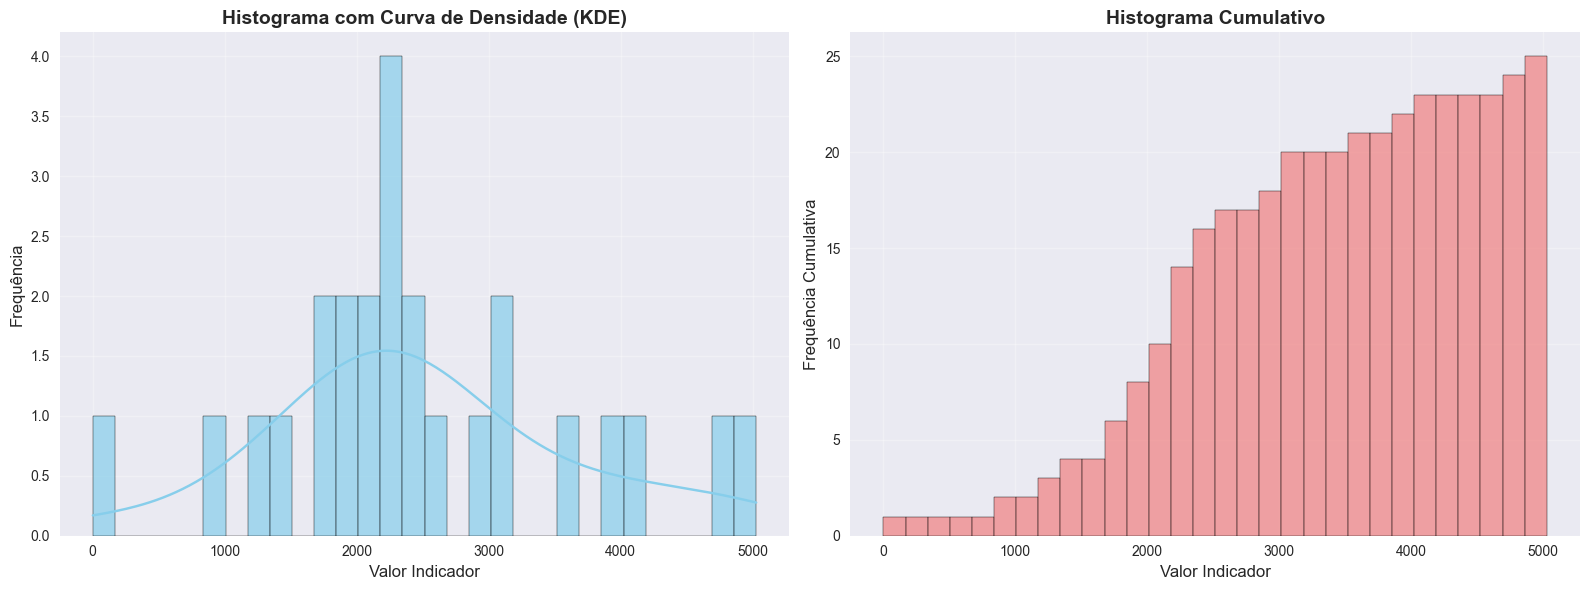


RESUMO DESCRITIVO - HISTOGRAMA:
   • O histograma mostra a distribuição de frequências dos valores indicadores.
   • A curva KDE (Kernel Density Estimation) suaviza a distribuição.
   • O histograma cumulativo mostra a acumulação de frequências.
   • Padrões observados: [Analisar visualmente - assimetria, multimodalidade, etc.]


In [37]:
if 'valor_indicador' in mamo_crajubar.columns:

    print("HISTOGRAMA - Distribuição de Frequências")
    print("-" * 60)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    sns.histplot(data=mamo_crajubar, x='valor_indicador', bins=30, kde=True, ax=ax1, color='skyblue', alpha=0.7)
    ax1.set_title('Histograma com Curva de Densidade (KDE)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Valor Indicador')
    ax1.set_ylabel('Frequência')
    ax1.grid(True, alpha=0.3)

    sns.histplot(data=mamo_crajubar, x='valor_indicador', bins=30, cumulative=True, ax=ax2, color='lightcoral', alpha=0.7)
    ax2.set_title('Histograma Cumulativo', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Valor Indicador')
    ax2.set_ylabel('Frequência Cumulativa')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nRESUMO DESCRITIVO - HISTOGRAMA:")
    print("   • O histograma mostra a distribuição de frequências dos valores indicadores.")
    print("   • A curva KDE (Kernel Density Estimation) suaviza a distribuição.")
    print("   • O histograma cumulativo mostra a acumulação de frequências.")
    print("   • Padrões observados: [Analisar visualmente - assimetria, multimodalidade, etc.]")


else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _BOXPLOT - Análise de Outliers e Quartis_


BOXPLOT - Análise de Outliers e Quartis
------------------------------------------------------------


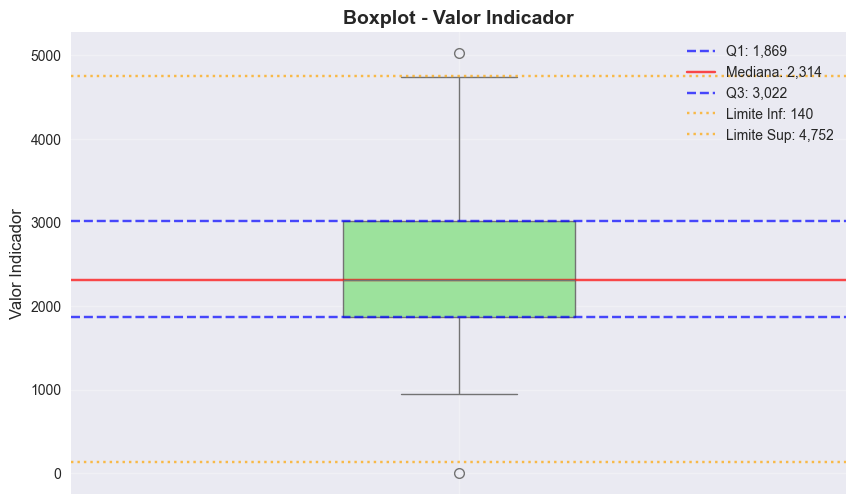


RESUMO DESCRITIVO - BOXPLOT:
   • A caixa representa o IQR (Q1 a Q3 - 50% central dos dados).
   • A linha dentro da caixa é a mediana (Q2).
   • Os 'bigodes' mostram a variação normal dos dados.
   • Pontos fora dos bigodes são outliers.
   • Neste caso: 2 outliers detectados.


In [38]:
if 'valor_indicador' in mamo_crajubar.columns:

    print(f"\nBOXPLOT - Análise de Outliers e Quartis")
    print("-" * 60)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=mamo_crajubar, y='valor_indicador', ax=ax, color='lightgreen', width=0.3)
    ax.set_title('Boxplot - Valor Indicador', fontsize=14, fontweight='bold')
    ax.set_ylabel('Valor Indicador')
    ax.grid(True, alpha=0.3)

    q1 = mamo_crajubar['valor_indicador'].quantile(0.25)
    q2 = mamo_crajubar['valor_indicador'].quantile(0.50)
    q3 = mamo_crajubar['valor_indicador'].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    ax.axhline(y=q1, color='blue', linestyle='--', alpha=0.7, label=f'Q1: {q1:,.0f}')
    ax.axhline(y=q2, color='red', linestyle='-', alpha=0.7, label=f'Mediana: {q2:,.0f}')
    ax.axhline(y=q3, color='blue', linestyle='--', alpha=0.7, label=f'Q3: {q3:,.0f}')
    ax.axhline(y=limite_inferior, color='orange', linestyle=':', alpha=0.7, label=f'Limite Inf: {limite_inferior:,.0f}')
    ax.axhline(y=limite_superior, color='orange', linestyle=':', alpha=0.7, label=f'Limite Sup: {limite_superior:,.0f}')

    ax.legend()
    plt.show()

    print("\nRESUMO DESCRITIVO - BOXPLOT:")
    print("   • A caixa representa o IQR (Q1 a Q3 - 50% central dos dados).")
    print("   • A linha dentro da caixa é a mediana (Q2).")
    print("   • Os 'bigodes' mostram a variação normal dos dados.")
    print("   • Pontos fora dos bigodes são outliers.")
    print(f"   • Neste caso: {len(mamo_crajubar[(mamo_crajubar['valor_indicador'] < limite_inferior) | (mamo_crajubar['valor_indicador'] > limite_superior)])} outliers detectados.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _GRÁFICO DE DISPERSÃO - Relações entre Variáveis_


GRÁFICO DE DISPERSÃO - Relações entre Variáveis
------------------------------------------------------------


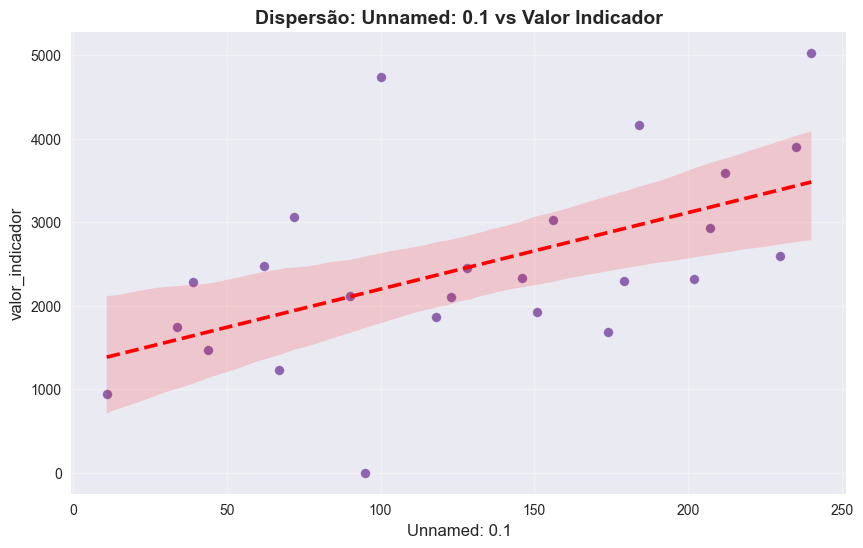


RESUMO DESCRITIVO - DISPERSÃO:
   • Análise da relação entre 'Unnamed: 0.1' e 'valor_indicador'.
   • Correlação de Pearson: 0.549
   • Correlação MODERADA detectada.


In [40]:
if 'valor_indicador' in mamo_crajubar.columns:

    print(f"\nGRÁFICO DE DISPERSÃO - Relações entre Variáveis")
    print("-" * 60)

    numeric_cols = mamo_crajubar.select_dtypes(include=['float64', 'int64']).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != 'valor_indicador']

    if len(numeric_cols) > 0:
        scatter_col = numeric_cols[0]

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=mamo_crajubar, x=scatter_col, y='valor_indicador', ax=ax, alpha=0.6, color='purple')
        ax.set_title(f'Dispersão: {scatter_col} vs Valor Indicador', fontsize=14, fontweight='bold')
        ax.set_xlabel(scatter_col)
        ax.set_ylabel('Valor Indicador')
        ax.grid(True, alpha=0.3)

        try:
            sns.regplot(data=mamo_crajubar, x=scatter_col, y='valor_indicador', ax=ax,
                       scatter_kws={'alpha':0.3}, line_kws={'color':'red', 'linestyle':'--'})
        except:
            pass

        plt.show()

        corr = mamo_crajubar[scatter_col].corr(mamo_crajubar['valor_indicador'])
        print("\nRESUMO DESCRITIVO - DISPERSÃO:")
        print(f"   • Análise da relação entre '{scatter_col}' e 'valor_indicador'.")
        print(f"   • Correlação de Pearson: {corr:.3f}")
        if abs(corr) > 0.7:
            print("   • Correlação FORTE detectada!")
        elif abs(corr) > 0.3:
            print("   • Correlação MODERADA detectada.")
        else:
            print("   • Correlação FRACA ou inexistente.")
    else:
        print("Não há outras colunas numéricas para análise de dispersão.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _HEATMAP DE CORRELAÇÃO - Relações entre Todas as Variáveis Numéricas_


HEATMAP DE CORRELAÇÃO - Relações entre Todas as Variáveis Numéricas
------------------------------------------------------------


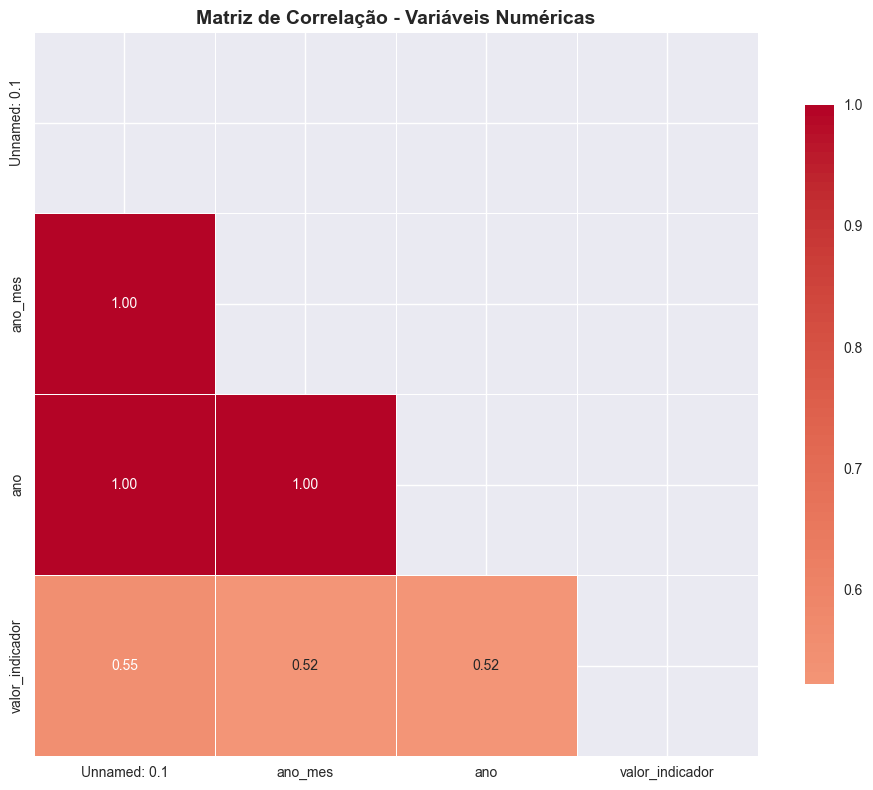


RESUMO DESCRITIVO - HEATMAP:
   • Valores próximos de +1: Correlação positiva forte
   • Valores próximos de -1: Correlação negativa forte
   • Valores próximos de 0: Correlação fraca ou inexistente
   • Correlações > 0.7 ou < -0.7 são consideradas fortes

Correlações Fortes Detectadas:
   • Unnamed: 0.1 ↔ ano_mes: 0.998
   • Unnamed: 0.1 ↔ ano: 0.998
   • ano_mes ↔ ano: 1.000


In [42]:
if 'valor_indicador' in mamo_crajubar.columns:

    print(f"\nHEATMAP DE CORRELAÇÃO - Relações entre Todas as Variáveis Numéricas")
    print("-" * 60)

    if len(numeric_cols) > 1:
        all_numeric = numeric_cols + ['valor_indicador']

        corr_matrix = mamo_crajubar[all_numeric].corr()

        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Máscara para triangular superior
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
                   square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, mask=mask, ax=ax)
        ax.set_title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print("\nRESUMO DESCRITIVO - HEATMAP:")
        print("   • Valores próximos de +1: Correlação positiva forte")
        print("   • Valores próximos de -1: Correlação negativa forte")
        print("   • Valores próximos de 0: Correlação fraca ou inexistente")
        print("   • Correlações > 0.7 ou < -0.7 são consideradas fortes")

        strong_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.7:
                    strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

        if strong_corr:
            print("\nCorrelações Fortes Detectadas:")
            for var1, var2, corr in strong_corr:
                print(f"   • {var1} ↔ {var2}: {corr:.3f}")
        else:
            print("\nNenhuma correlação forte detectada entre as variáveis.")
    else:
        print("Poucas colunas numéricas para análise de correlação.")


else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _QQ-PLOT - Verificação de Normalidade_


QQ-PLOT - Verificação de Normalidade
------------------------------------------------------------


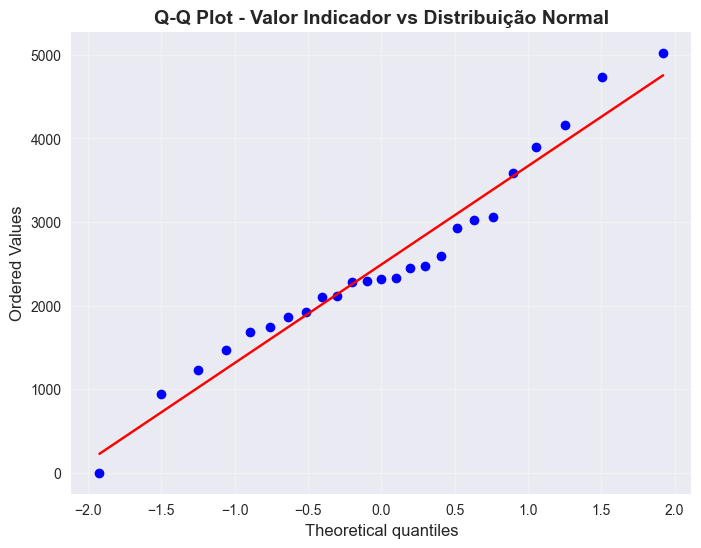


RESUMO DESCRITIVO - QQ-PLOT:
   • O Q-Q plot compara os quantis dos dados com uma distribuição normal.
   • Pontos próximos da linha diagonal indicam normalidade.
   • Desvios da linha indicam não-normalidade.
   • Teste de Shapiro-Wilk: Estatística = 0.9648, p-valor = 0.5181
   • Conclusão: Dados parecem seguir distribuição normal (p > 0.05)


In [43]:
if 'valor_indicador' in mamo_crajubar.columns:

    print(f"\nQQ-PLOT - Verificação de Normalidade")
    print("-" * 60)

    from scipy import stats

    fig, ax = plt.subplots(figsize=(8, 6))
    stats.probplot(mamo_crajubar['valor_indicador'].dropna(), dist="norm", plot=ax)
    ax.set_title('Q-Q Plot - Valor Indicador vs Distribuição Normal', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.show()

    try:
        stat, p_value = stats.shapiro(mamo_crajubar['valor_indicador'].dropna().sample(min(5000, len(mamo_crajubar))))
        print("\nRESUMO DESCRITIVO - QQ-PLOT:")
        print("   • O Q-Q plot compara os quantis dos dados com uma distribuição normal.")
        print("   • Pontos próximos da linha diagonal indicam normalidade.")
        print("   • Desvios da linha indicam não-normalidade.")
        print(f"   • Teste de Shapiro-Wilk: Estatística = {stat:.4f}, p-valor = {p_value:.4f}")
        if p_value > 0.05:
            print("   • Conclusão: Dados parecem seguir distribuição normal (p > 0.05)")
        else:
            print("   • Conclusão: Dados NÃO seguem distribuição normal (p ≤ 0.05)")
    except:
        print("Não foi possível realizar o teste de normalidade.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

VISUALIZAÇÕES REALIZADAS: <br>
   • Histograma com KDE e cumulativo<br>
   • Boxplot com identificação de outliers<br>
   • Gráfico de dispersão<br>
   • Gráfico de barras <br>
   • Heatmap de correlação <br>
   • Q-Q plot para normalidade<br>

INSIGHTS PRINCIPAIS:<br>
   • Analisar a forma da distribuição no histograma<br>
   • Identificar outliers no boxplot<br>
   • Verificar relações lineares no scatter plot<br>
   • Observar padrões categóricos no gráfico de barras<br>
   • Detectar multicolinearidade no heatmap<br>
   • Avaliar normalidade no Q-Q plot

##### _GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR ANO E CIDADE - EVOLUÇÃO TEMPORAL_

GRÁFICO DE BARRAS: DISTRIBUIÇÃO DE MAMOGRAFIAS POR ANO E CIDADE



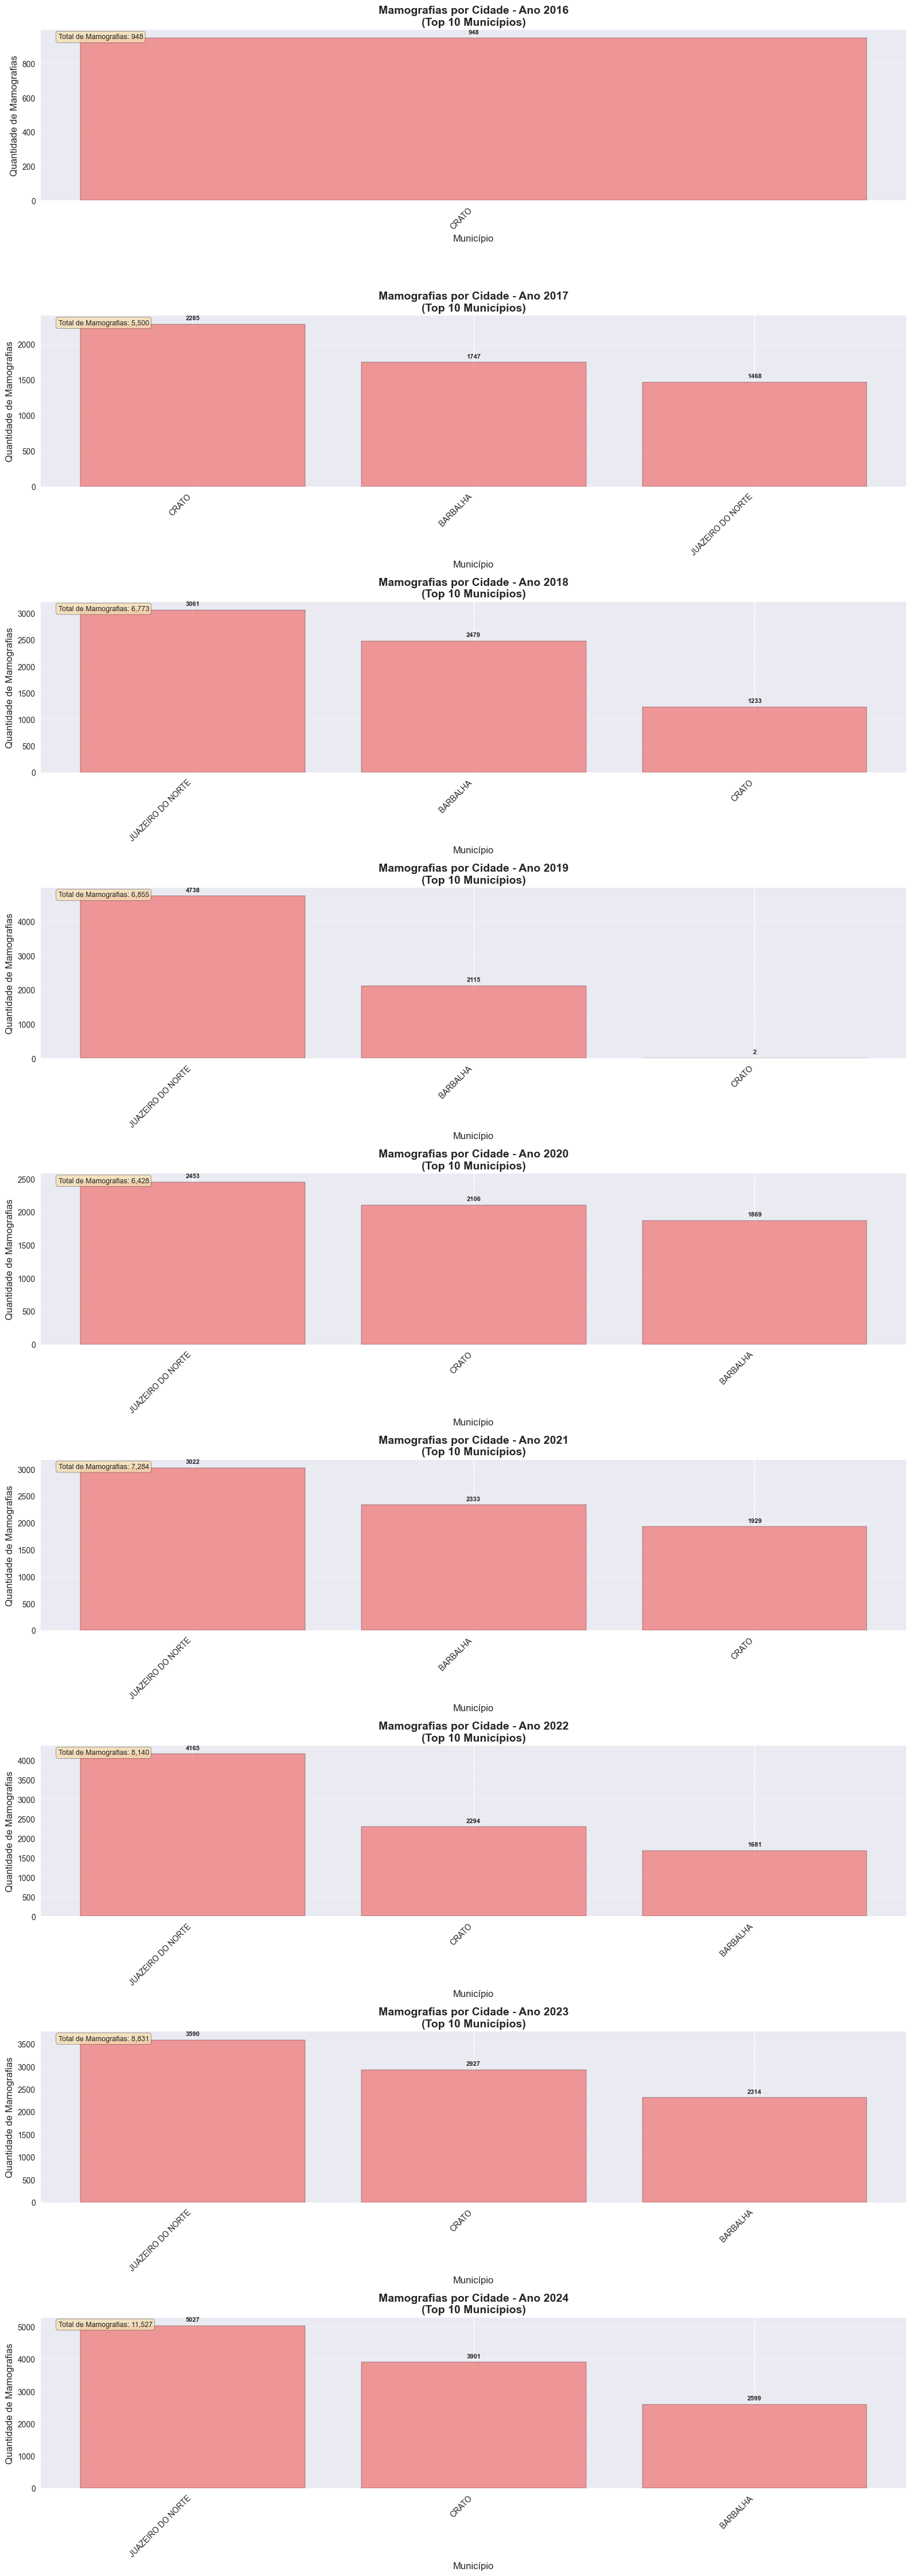

ESTATÍSTICAS GERAIS POR ANO
--------------------------------------------------
Ano 2016:
  • Municípios com dados: 1
  • Total de mamografias: 948

Ano 2017:
  • Municípios com dados: 3
  • Total de mamografias: 5,500

Ano 2018:
  • Municípios com dados: 3
  • Total de mamografias: 6,773

Ano 2019:
  • Municípios com dados: 3
  • Total de mamografias: 6,855

Ano 2020:
  • Municípios com dados: 3
  • Total de mamografias: 6,428

Ano 2021:
  • Municípios com dados: 3
  • Total de mamografias: 7,284

Ano 2022:
  • Municípios com dados: 3
  • Total de mamografias: 8,140

Ano 2023:
  • Municípios com dados: 3
  • Total de mamografias: 8,831

Ano 2024:
  • Municípios com dados: 3
  • Total de mamografias: 11,527

TOP 5 MUNICÍPIOS POR ANO
--------------------------------------------------

Ano 2016:
Cidade Mamografia
 CRATO        948

Ano 2017:
           Cidade Mamografia
            CRATO      2,285
         BARBALHA      1,747
JUAZEIRO DO NORTE      1,468

Ano 2018:
           Cidade Mamo

In [46]:
print("GRÁFICO DE BARRAS: DISTRIBUIÇÃO DE MAMOGRAFIAS POR ANO E CIDADE\n")

if all(col in mamo_crajubar.columns for col in ['valor_indicador', 'ano_mes', 'municipio', 'tipo_exame']):

    mamo_crajubar['ano'] = mamo_crajubar['ano_mes'].astype(str).str[:4].astype(int)

    # Filtra apenas mamografias
    mamo_data = mamo_crajubar[
        mamo_crajubar['tipo_exame'] == 'Mamografia'
    ].copy()

    # Agrupa por ano e município
    mamo_year_city = (
        mamo_data
        .groupby(['ano', 'municipio'])['valor_indicador']
        .sum()
        .reset_index()
    )

    mamo_year_city.columns = ['Ano', 'Cidade', 'Mamografia']

    anos_unicos = sorted(mamo_year_city['Ano'].unique())

    fig, axes = plt.subplots(len(anos_unicos), 1,
                             figsize=(16, 5 * len(anos_unicos)))

    if len(anos_unicos) == 1:
        axes = [axes]

    for i, ano in enumerate(anos_unicos):
        ax = axes[i]

        data_ano = mamo_year_city[
            mamo_year_city['Ano'] == ano
        ].copy()

        data_ano_top = data_ano.nlargest(10, 'Mamografia')

        if len(data_ano_top) > 0:

            x = np.arange(len(data_ano_top))

            bars = ax.bar(
                x,
                data_ano_top['Mamografia'],
                color='lightcoral',
                alpha=0.8,
                edgecolor='black'
            )

            ax.set_title(
                f'Mamografias por Cidade - Ano {ano}\n(Top 10 Municípios)',
                fontsize=14,
                fontweight='bold'
            )

            ax.set_xlabel('Município')
            ax.set_ylabel('Quantidade de Mamografias')

            ax.set_xticks(x)
            ax.set_xticklabels(
                data_ano_top['Cidade'],
                rotation=45,
                ha='right'
            )

            ax.grid(True, axis='y', alpha=0.3)

            max_height = data_ano_top['Mamografia'].max()

            for bar in bars:
                height = bar.get_height()

                if height > 0:
                    ax.text(
                        bar.get_x() + bar.get_width()/2,
                        height + max_height * 0.02,
                        f'{int(height)}',
                        ha='center',
                        va='bottom',
                        fontsize=8,
                        fontweight='bold'
                    )

            total_mamo = data_ano_top['Mamografia'].sum()

            ax.text(
                0.02,
                0.98,
                f'Total de Mamografias: {total_mamo:,.0f}',
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(
                    boxstyle='round',
                    facecolor='wheat',
                    alpha=0.8
                )
            )

        else:
            ax.text(
                0.5,
                0.5,
                f'Sem dados para o ano {ano}',
                ha='center',
                va='center'
            )

    plt.tight_layout()
    plt.show()

    print("ESTATÍSTICAS GERAIS POR ANO")
    print("-" * 50)

    for ano in anos_unicos:

        data_ano = mamo_year_city[
            mamo_year_city['Ano'] == ano
        ]

        total_cidades = data_ano['Cidade'].nunique()
        total_mamo = data_ano['Mamografia'].sum()

        print(f"Ano {ano}:")
        print(f"  • Municípios com dados: {total_cidades}")
        print(f"  • Total de mamografias: {total_mamo:,.0f}")
        print()

    print("TOP 5 MUNICÍPIOS POR ANO")
    print("-" * 50)

    for ano in anos_unicos:

        data_ano_top5 = (
            mamo_year_city[mamo_year_city['Ano'] == ano]
            .nlargest(5, 'Mamografia')
        )

        print(f"\nAno {ano}:")

        print(
            data_ano_top5[
                ['Cidade', 'Mamografia']
            ].to_string(
                index=False,
                formatters={
                    'Mamografia': '{:,.0f}'.format
                }
            )
        )

else:
    print("Colunas necessárias não encontradas.")
    print("Necessárias: valor_indicador, ano_mes, municipio, tipo_exame")
    print("Disponíveis:", mamo_crajubar.columns.tolist())

INTERPRETAÇÃO DOS GRÁFICOS:<br>
• Cada subplot representa um ano diferente <br>
• Barras azuis: Exames de citoplastia por cidade <br>
• Barras vermelhas: Exames de mamografia por cidade <br>
• Top 10 cidades: Ordenadas por volume total de exames <br>
• Comparação temporal: Permite ver evolução ano a ano <br>

INSIGHTS PARA ANÁLISE TEMPORAL: <br>
• Cidades que mantêm ou aumentam cobertura ao longo dos anos <br>
• Diferenças na adoção de citoplastia vs mamografia por período <br>
• Identificação de cidades com queda na cobertura preventiva <br>
• Padrões sazonais ou tendências regionais

##### _Gráfico de barras: Distribuido por cidade e acumulo geral_

GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR CIDADES - MAMOGRAFIA



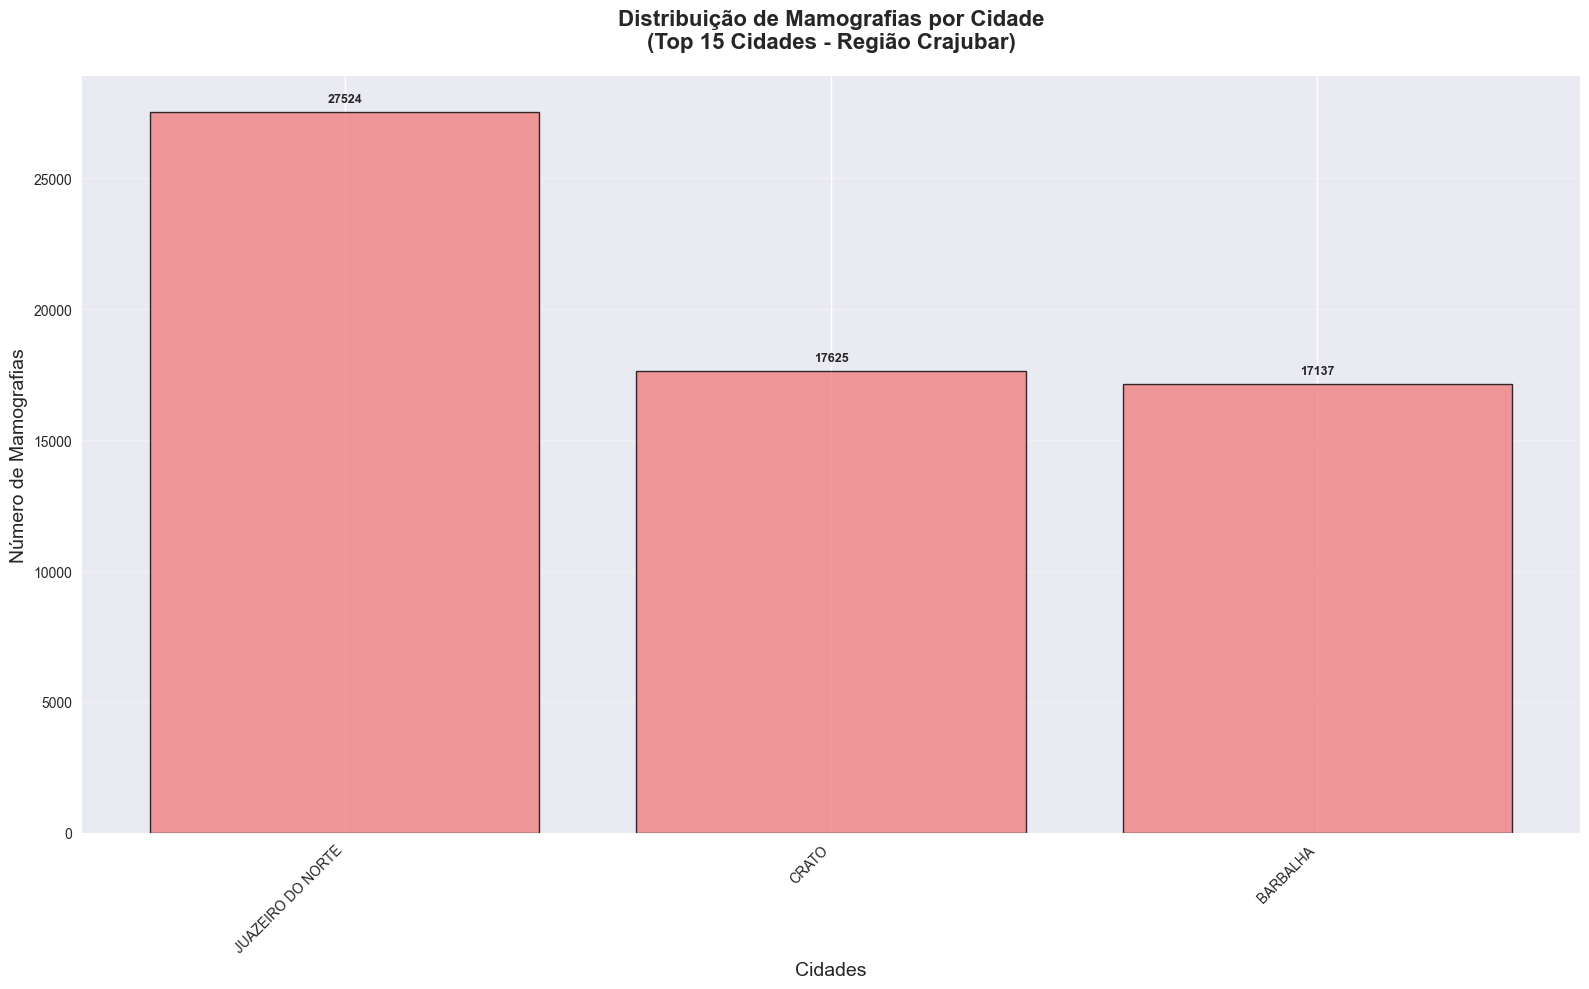


ESTATÍSTICAS DO GRÁFICO:
--------------------------------------------------
Total de cidades analisadas: 3
Cidades mostradas no gráfico: 3 (top 15)
Total de mamografias: 62,286

TOP CIDADE:
• Maior número de mamografias: JUAZEIRO DO NORTE (27,524)

TABELA DETALHADA (Top 15 Cidades):
--------------------------------------------------------------------------------
           Cidade Mamografia
JUAZEIRO DO NORTE     27,524
            CRATO     17,625
         BARBALHA     17,137

INTERPRETAÇÃO:
• Valores representam o total de mamografias por município.
• O gráfico mostra as 15 cidades com maior volume de exames.


In [52]:
print("GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR CIDADES - MAMOGRAFIA\n")

required_cols = {'valor_indicador', 'municipio', 'tipo_exame'}

if required_cols.issubset(set(mamo_crajubar.columns)):

    # Filtra apenas mamografia (robusto para maiúsculas/minúsculas)
    mamo_mask = mamo_crajubar['tipo_exame'].astype(str).str.contains(
        'mamo', case=False, na=False
    )

    mamo_group = (
        mamo_crajubar[mamo_mask]
        .groupby('municipio', as_index=False)['valor_indicador']
        .sum()
        .rename(columns={'valor_indicador': 'Mamografia'})
    )

    # Como agora só existe mamografia, não precisa de merge
    city_exams = mamo_group.copy()
    city_exams.columns = ['Cidade', 'Mamografia']
    city_exams['Total'] = city_exams['Mamografia']

    city_exams_top = city_exams.nlargest(15, 'Total').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(16, 10))

    x = np.arange(len(city_exams_top))

    bars = ax.bar(
        x,
        city_exams_top['Mamografia'],
        color='lightcoral',
        alpha=0.8,
        edgecolor='black',
        linewidth=1
    )

    ax.set_title(
        'Distribuição de Mamografias por Cidade\n(Top 15 Cidades - Região Crajubar)',
        fontsize=16,
        fontweight='bold',
        pad=20
    )

    ax.set_xlabel('Cidades', fontsize=14)
    ax.set_ylabel('Número de Mamografias', fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels(city_exams_top['Cidade'], rotation=45, ha='right')

    ax.grid(True, axis='y', alpha=0.3)

    # Anotações
    max_height = city_exams_top['Mamografia'].max()

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + max_height * 0.01,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    # =========================
    # ESTATÍSTICAS
    # =========================

    print("\nESTATÍSTICAS DO GRÁFICO:")
    print("-" * 50)
    print(f"Total de cidades analisadas: {len(city_exams)}")
    print(f"Cidades mostradas no gráfico: {len(city_exams_top)} (top 15)")
    print(f"Total de mamografias: {city_exams['Mamografia'].sum():,}")

    if len(city_exams_top) > 0:
        top_city = city_exams_top.loc[
            city_exams_top['Mamografia'].idxmax()
        ]

        print("\nTOP CIDADE:")
        print(f"• Maior número de mamografias: {top_city['Cidade']} ({top_city['Mamografia']:,})")

    print("\nTABELA DETALHADA (Top 15 Cidades):")
    print("-" * 80)

    print(
        city_exams_top[['Cidade', 'Mamografia']].to_string(
            index=False,
            formatters={'Mamografia': '{:,}'.format}
        )
    )

    print("\nINTERPRETAÇÃO:")
    print("• Valores representam o total de mamografias por município.")
    print("• O gráfico mostra as 15 cidades com maior volume de exames.")

else:
    missing = required_cols.difference(set(mamo_crajubar.columns))
    print("Colunas necessárias não encontradas:", missing)
    print("Colunas disponíveis:", mamo_crajubar.columns.tolist())